Install required libraries and restart kernel:

In [1]:
%pip install tensorflow==2.10 
%pip install tensorflow-directml-plugin
%pip install matplotlib==3.9.2
%pip install numpy==1.26.4
%pip install scipy==1.14.1
%pip install scikit-learn==1.5.2
%pip install tqdm
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


...


[notice] A new release of pip available: 22.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip available: 22.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip available: 22.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Import libraries:

In [2]:
# Standard library imports
import os
import zipfile
import urllib.request
import logging
from collections import Counter
from datetime import datetime
from typing import Optional
from pathlib import Path

# Third-party imports
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# TensorFlow imports
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.applications import VGG16, MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, 
    Flatten, 
    Dropout, 
    BatchNormalization, 
    GlobalAveragePooling2D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.mixed_precision import set_global_policy

In [3]:
tf.config.list_physical_devices('GPU')


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [4]:
# Logger setup
_LOGGER = logging.getLogger(__name__)


def setup_logging(debug: bool = True) -> None:
    """Configure logging with proper timestamp formatting."""
    level = logging.DEBUG if debug else logging.INFO
    logging.basicConfig(
        level=level,
        format="%(asctime)s %(levelname)s: %(message)s",
        datefmt="%Y-%m-%d %H:%M:%S",
    )
    _LOGGER.setLevel(level)


# Initialize logging 
setup_logging(debug = True)

Download and extract dataset

In [5]:
def download_dataset(url: str, output_file: str) -> Path:
    """
    Download a dataset from a URL with tqdm progress bar and logging.

    Creates parent directories if needed, shows real-time download progress
    via tqdm (bytes, unit scaling, rate), and logs start/completion with final size.

    Args:
        url (str): Remote URL to download (e.g., ZIP dataset).
        output_file (str): Local path to save file (str or Path-like).

    Returns:
        Path: Path to the downloaded file.

    Raises:
        urllib.error.URLError: If download fails (network, invalid URL).
        OSError: If file write fails (permissions, disk space).

    Example:
        >>> download_dataset("https://example.com/data.zip", "data/fruits.zip")
        PosixPath('data/fruits.zip')
    """
    output_file = Path(output_file)
    _LOGGER.info(f"📥 Downloading {url}...")
    
    output_file.parent.mkdir(parents=True, exist_ok=True)
    
    def tqdm_hook(t):
        last_b = [0]
        def inner(b=1, bs=1, tsize=None):
            downloaded = b * bs
            t.update(downloaded - last_b[0])
            last_b[0] = downloaded
        return inner
    
    urllib.request.urlretrieve(url, str(output_file), reporthook=tqdm_hook(tqdm(unit='B', unit_scale=True)))
    
    file_size = os.path.getsize(output_file) / (1024**2)
    _LOGGER.info(f"✅ Download COMPLETE ({file_size:.1f} MB)")
    return output_file



def extract_zip_in_chunks(
    zip_path: str, 
    extract_to: str, 
    batch_size: int = 1000,
    overwrite: bool = False
) -> None:
    """
    Extract large ZIP file in memory-efficient batches with progress logging.

    Processes files in batches to avoid loading the entire ZIP index into memory.
    Skips directories and existing files (unless overwrite=True). Logs batch progress.

    Args:
        zip_path (str): Path to input ZIP file (must exist).
        extract_to (str): Root directory to extract contents (created if needed).
        batch_size (int): Number of files to extract per batch (default: 1000).
        overwrite (bool): Extract even if files exist (default: False).

    Returns:
        None

    Raises:
        FileNotFoundError: If zip_path does not exist.
        zipfile.BadZipFile: If ZIP is corrupted/invalid.
        PermissionError: If cannot write to extract_to.

    Example:
        >>> extract_zip_in_chunks("data/fruits.zip", "data/extracted", batch_size=500)
        Extracts fruits-360 dataset in 500-file chunks.
    """
    zip_path = Path(zip_path)
    extract_to = Path(extract_to)
    
    if not zip_path.exists():
        raise FileNotFoundError(f"❌ ZIP not found: {zip_path}")
    
    _LOGGER.info(f"📦 Extracting {zip_path} → {extract_to} (batch={batch_size})")
    extract_to.mkdir(parents=True, exist_ok=True)
    
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        file_list = zip_ref.namelist()
        total_files = len(file_list)
        _LOGGER.debug(f"Found {total_files} files")
        
        for i in range(0, total_files, batch_size):
            batch = file_list[i:i + batch_size]
            extracted_count = 0
            
            for file_path in batch:
                if file_path.endswith('/'):
                    continue
                
                target_path = extract_to / file_path
                if overwrite or not target_path.exists():
                    target_path.parent.mkdir(parents=True, exist_ok=True)
                    zip_ref.extract(file_path, extract_to)
                    extracted_count += 1
            
            progress = (i + batch_size) / total_files * 100
            _LOGGER.info(
                f"📊 Batch {i//batch_size + 1}: "
                f"{min(i + batch_size, total_files)}/{total_files} "
                f"({progress:.1f}%)"
            )
    
    _LOGGER.info(f"✅ Extraction done: {extract_to}")


def prepare_dataset(
    dataset_url: str,
    zip_path: str,
    extract_path: str,
    fallback_urls: list[str] | None = None,
    force_download: bool = False,
    force_extract: bool = False,
    batch_size: int = 1000,
    auto_cleanup: bool = False,
) -> tuple[Path, Path]:
    """
    Download and extract dataset with fallback URLs, retries, and cleanup.

    Tries primary URL + fallbacks until success. Downloads if ZIP missing/forced,
    extracts in chunks if dir missing/forced. Cleans up ZIP post-extraction if enabled.
    Handles failures gracefully, raises only if all URLs fail.

    Args:
        dataset_url (str): Primary URL for ZIP download.
        zip_path (str): Local path to save ZIP (created if missing).
        extract_path (str): Dir to extract contents (created if missing).
        fallback_urls (list[str] | None): Backup URLs if primary fails (default: None).
        force_download (bool): Re-download even if ZIP exists (default: False).
        force_extract (bool): Re-extract even if dir exists (default: False).
        batch_size (int): Files per extract batch (default: 1000).
        auto_cleanup (bool): Delete ZIP after successful extraction (default: False).

    Returns:
        tuple[Path, Path]: (zip_path, extract_path) - paths to ZIP and extracted data.

    Raises:
        RuntimeError: If all URLs fail to download.
        urllib.error.URLError: Download failures (propagated from download_dataset).
        zipfile.BadZipFile: Corrupted ZIP (from extract_zip_in_chunks).

    Example:
        >>> zip_p, ext_p = prepare_dataset(
        ...     "https://example.com/fruits.zip",
        ...     "data/fruits.zip",
        ...     "data/fruits-extracted",
        ...     fallback_urls=["https://backup.com/fruits.zip"],
        ...     auto_cleanup=True
        ... )
        >>> ext_p / "Training"  # Contains extracted images
        PosixPath('data/fruits-extracted/Training')
    """

    zip_path = Path(zip_path)
    extract_path = Path(extract_path)
    
    urls_to_try = [dataset_url]
    if fallback_urls:
        urls_to_try.extend([u for u in fallback_urls if u != dataset_url])
    
    for url in urls_to_try:
        try:
            _LOGGER.info(f"🔄 Attempting: {url}")
            
            if force_download or not zip_path.exists():
                zip_path = download_dataset(url, zip_path)
            
            if force_extract or not extract_path.exists():
                extract_zip_in_chunks(zip_path, extract_path, batch_size)
            
            _LOGGER.info(f"✅ SUCCESS: {url}")
            break
            
        except Exception as e:
            _LOGGER.warning(f"❌ Failed {url}: {str(e)[:100]}...")
            continue
    else:
        raise RuntimeError(f"All {len(urls_to_try)} URLs failed!")
    
    if auto_cleanup and zip_path.exists() and extract_path.exists():
        zip_path.unlink()
        _LOGGER.info("🧹 ZIP cleaned up")
    
    _LOGGER.info(f"🎉 Dataset ready → {zip_path} | {extract_path}")
    return zip_path, extract_path


In [6]:
# Dataset configuration
IBM_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/4yIRGlIpNfKEGJYMhZV52g/fruits-360-original-size.zip"
GITHUB_URL = "https://github.com/fruits-360/fruits-360-original-size/archive/refs/heads/main.zip"
LOCAL_ZIP = "fruits-360-original-size.zip"
EXTRACT_DIR = "fruits-360-original-size"

# Download and extract dataset
zip_file, data_dir = prepare_dataset(
    dataset_url=GITHUB_URL,
    zip_path=LOCAL_ZIP,
    extract_path=EXTRACT_DIR,
    fallback_urls=[IBM_URL]
)


2026-04-12 14:11:44 INFO: 🔄 Attempting: https://github.com/fruits-360/fruits-360-original-size/archive/refs/heads/main.zip
2026-04-12 14:11:44 INFO: ✅ SUCCESS: https://github.com/fruits-360/fruits-360-original-size/archive/refs/heads/main.zip
2026-04-12 14:11:44 INFO: 🎉 Dataset ready → fruits-360-original-size.zip | fruits-360-original-size


In [7]:
# Directory structure 

# Ensure that your data set is organized as follows: 


# dataset/
# ├── train/
# │   ├── Class1/
# │   ├── Class2/
# │   ├── Class3/
# │   └── (other classes...)
# ├── val/
# │   ├── Class1/
# │   ├── Class2/
# │   ├── Class3/
# │   └── (other classes...)
# └── test/
#     ├── Class1/
#     ├── Class2/
#     ├── Class3/
#     └── (other classes...)


# Each subdirectory under train and val should contain images of the respective fruit category. 

Set up data generators for training, validation, and testing with augmentation

In [8]:

# Set dataset paths
train_dir = 'fruits-360-original-size/fruits-360-original-size-main/Training'
val_dir = 'fruits-360-original-size/fruits-360-original-size-main/Test' # Validation' Do not use validation split since it gives only 22% accuracy, TODO: find out why
test_dir = 'fruits-360-original-size/fruits-360-original-size-main/Test'

batch_size = 128


train_datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
)

val_datagen = ImageDataGenerator(rescale=1.0/255.0)
test_datagen = ImageDataGenerator(rescale=1.0/255.0)


train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(128, 128),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True,
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(128, 128),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False,
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(128, 128),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False,
)

print(f"Classes: {train_generator.num_classes}")



Found 49912 images belonging to 141 classes.
Found 24810 images belonging to 141 classes.
Found 24810 images belonging to 141 classes.
Classes: 141


Verify Pipeline
Expected: VGG16 normalized [0,1]

In [9]:
# Test one batch
x, _ = next(test_generator)
print("✅ Pipeline check:")
print(f"Input range: [{x.min():.3f}, {x.max():.3f}]")
print(f"Channel means: \n{x.mean(axis=(0,1)).round(3)}")  # Vector!
print(f"Global mean: {x.mean():.3f}")
print(f"Shape: {x.shape}")


✅ Pipeline check:
Input range: [0.000, 1.000]
Channel means: 
[[0.949 0.947 0.944]
 [0.895 0.881 0.874]
 [0.857 0.834 0.824]
 [0.828 0.798 0.784]
 [0.803 0.766 0.748]
 [0.781 0.738 0.718]
 [0.759 0.71  0.688]
 [0.739 0.685 0.661]
 [0.72  0.661 0.635]
 [0.703 0.641 0.612]
 [0.687 0.62  0.589]
 [0.672 0.601 0.569]
 [0.657 0.583 0.549]
 [0.644 0.566 0.531]
 [0.631 0.55  0.513]
 [0.618 0.534 0.496]
 [0.606 0.52  0.48 ]
 [0.595 0.505 0.464]
 [0.584 0.492 0.45 ]
 [0.574 0.479 0.436]
 [0.564 0.467 0.422]
 [0.554 0.454 0.408]
 [0.543 0.441 0.393]
 [0.532 0.427 0.379]
 [0.522 0.415 0.365]
 [0.513 0.403 0.352]
 [0.503 0.391 0.339]
 [0.494 0.38  0.327]
 [0.486 0.37  0.315]
 [0.479 0.36  0.304]
 [0.472 0.352 0.295]
 [0.465 0.342 0.284]
 [0.458 0.334 0.275]
 [0.453 0.326 0.266]
 [0.446 0.318 0.257]
 [0.441 0.31  0.249]
 [0.435 0.303 0.24 ]
 [0.43  0.296 0.233]
 [0.426 0.29  0.226]
 [0.422 0.285 0.219]
 [0.418 0.28  0.213]
 [0.415 0.276 0.209]
 [0.412 0.271 0.203]
 [0.409 0.267 0.199]
 [0.407 0.264 

Class Balance Check. Higher entropy = more balanced → easier.

🔍 Scanning **TRAIN** (49912 imgs, 141 classes)...


TRAIN: 100%|██████████| 390/390 [02:26<00:00,  2.65it/s]



📊 **FULL TRAIN ANALYSIS**
📈 Total images: **49,912**
🎯 Classes detected: **141**
❌ Zero-sample classes: **0** (0.0%)
⚠️  Rare classes (<5 imgs): **0** (0.0%)
📊 Avg imgs/class: **354** (min=96.0, max=648.0)

🥇 **TOP 10 Classes** (by count):
   1. Cherimoya 1               648.0 imgs
   2. Dates 2                   639.0 imgs
   3. Pear 9                    620.0 imgs
   4. Cucumber 6                618.0 imgs
   5. Peach 3                   618.0 imgs
   6. Onion 2                   510.0 imgs
   7. Quince 4                  500.0 imgs
   8. Avocado Black 2           492.0 imgs
   9. Apple 17                  489.0 imgs
  10. Quince 3                  488.0 imgs

💀 **BOTTOM 10 Classes** (fewest):
   1. cabbage_white_1            96.0 imgs
   2. Zucchini Green 1           96.0 imgs
   3. Cabbage red 1              99.0 imgs
   4. Cucumber 1                100.0 imgs
   5. Carrot 1                  101.0 imgs
   6. Peanut shell 1x 1         106.0 imgs
   7. Pear 3                    144.

VAL: 100%|██████████| 194/194 [00:29<00:00,  6.59it/s]



📊 **FULL VAL ANALYSIS**
📈 Total images: **24,810**
🎯 Classes detected: **141**
❌ Zero-sample classes: **0** (0.0%)
⚠️  Rare classes (<5 imgs): **0** (0.0%)
📊 Avg imgs/class: **176** (min=47.0, max=320.0)

🥇 **TOP 10 Classes** (by count):
   1. Cherimoya 1               320.0 imgs
   2. Dates 2                   319.0 imgs
   3. Pear common 1             308.0 imgs
   4. Cucumber 6                307.0 imgs
   5. Peach 3                   306.0 imgs
   6. Onion 2                   255.0 imgs
   7. Quince 4                  249.0 imgs
   8. Avocado Black 2           246.0 imgs
   9. Apple 17                  243.0 imgs
  10. Apple 18                  242.0 imgs

💀 **BOTTOM 10 Classes** (fewest):
   1. cabbage_white_1            47.0 imgs
   2. Zucchini Green 1           47.0 imgs
   3. Cabbage red 1              49.0 imgs
   4. Carrot 1                   50.0 imgs
   5. Cucumber 1                 50.0 imgs
   6. Peanut shell 1x 1          52.0 imgs
   7. Pear 5                     72.0 

TEST: 100%|██████████| 194/194 [00:26<00:00,  7.44it/s]



📊 **FULL TEST ANALYSIS**
📈 Total images: **24,810**
🎯 Classes detected: **141**
❌ Zero-sample classes: **0** (0.0%)
⚠️  Rare classes (<5 imgs): **0** (0.0%)
📊 Avg imgs/class: **176** (min=47.0, max=320.0)

🥇 **TOP 10 Classes** (by count):
   1. Cherimoya 1               320.0 imgs
   2. Dates 2                   319.0 imgs
   3. Pear common 1             308.0 imgs
   4. Cucumber 6                307.0 imgs
   5. Peach 3                   306.0 imgs
   6. Onion 2                   255.0 imgs
   7. Quince 4                  249.0 imgs
   8. Avocado Black 2           246.0 imgs
   9. Apple 17                  243.0 imgs
  10. Apple 18                  242.0 imgs

💀 **BOTTOM 10 Classes** (fewest):
   1. cabbage_white_1            47.0 imgs
   2. Zucchini Green 1           47.0 imgs
   3. Cabbage red 1              49.0 imgs
   4. Carrot 1                   50.0 imgs
   5. Cucumber 1                 50.0 imgs
   6. Peanut shell 1x 1          52.0 imgs
   7. Pear 5                     72.0

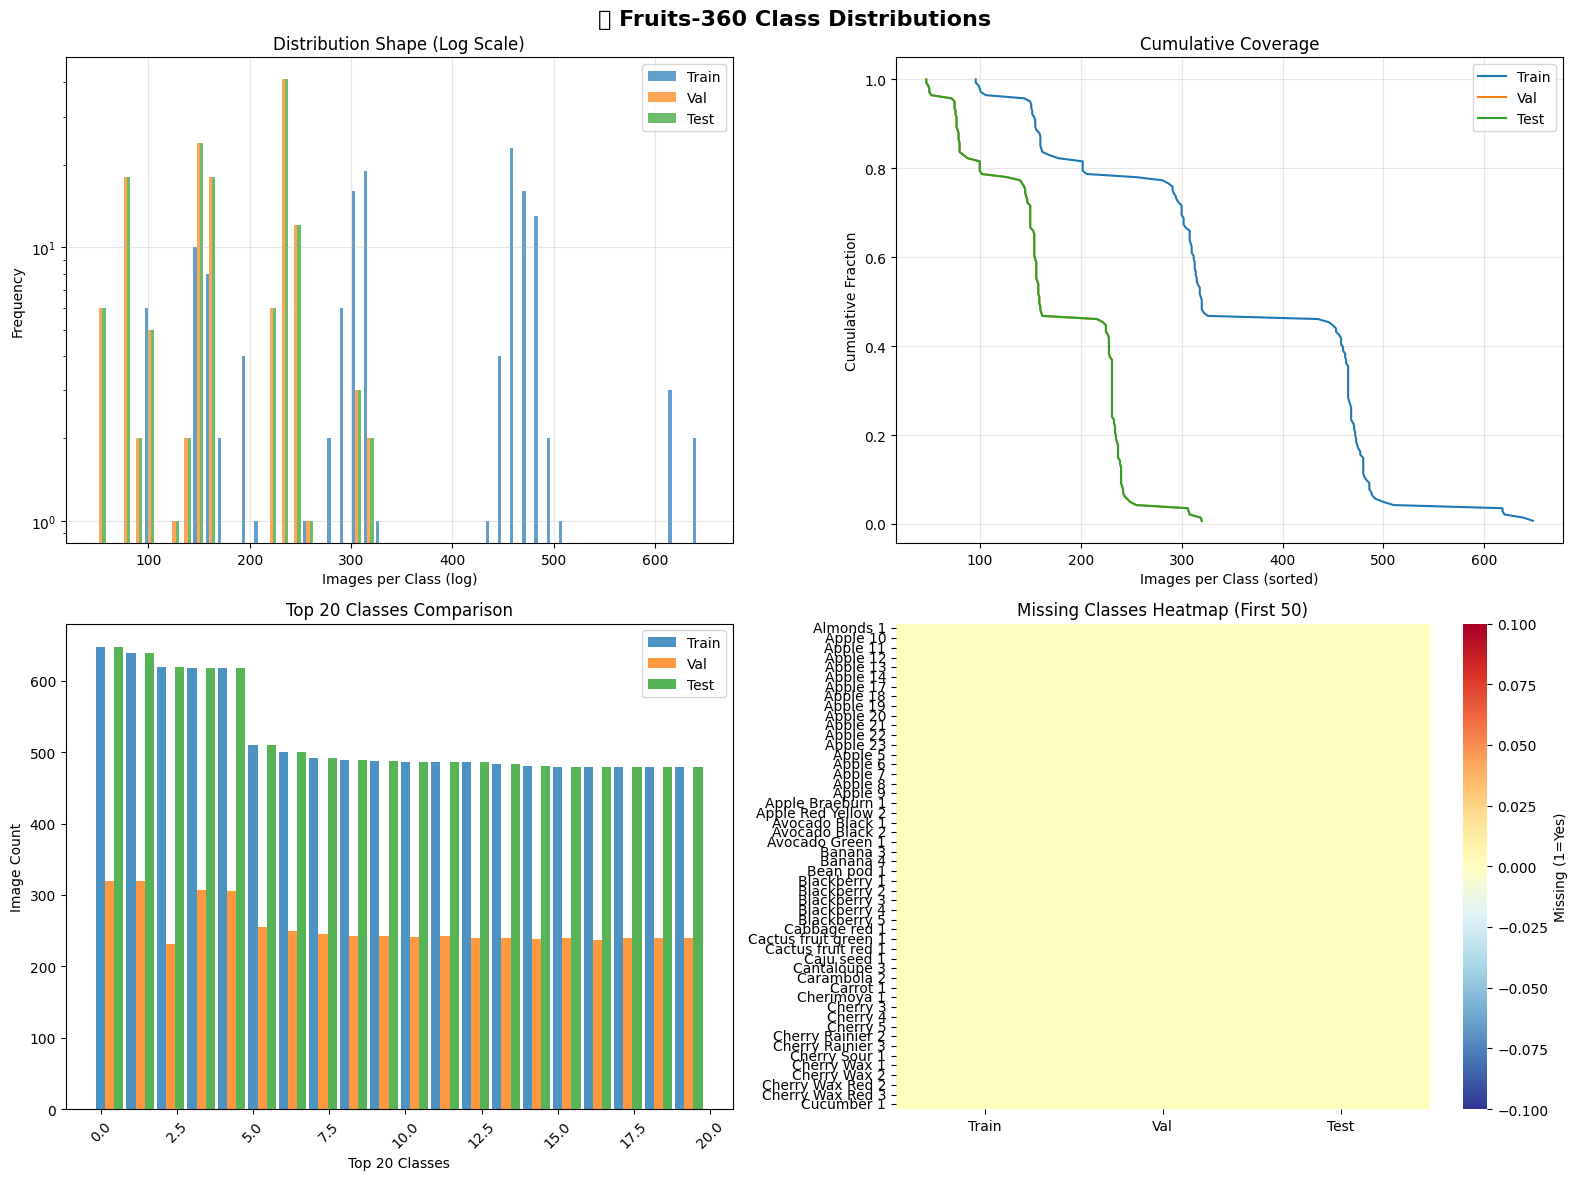

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter
from tqdm import tqdm
import warnings
import logging
from datetime import datetime


# SUPPRESS ALL DEBUG (matplotlib 3.9 compatible)
warnings.filterwarnings('ignore')
logging.getLogger('matplotlib').setLevel(logging.ERROR)
logging.getLogger('matplotlib.font_manager').disabled = True
plt.rcParams['toolbar'] = 'None'  # No toolbar spam


def full_class_dist(generator, name, class_names=None):
    """Enhanced FULL generator analysis + plots."""
    generator.reset()
    counts = np.zeros(generator.num_classes)
    total_samples = 0
    
    print(f"🔍 Scanning **{name}** ({generator.samples} imgs, {generator.num_classes} classes)...")
    for step in tqdm(range(generator.samples // generator.batch_size + 1), desc=name):
        try:
            _, y = next(generator)
            batch_labels = np.argmax(y, axis=1)
            counts += np.bincount(batch_labels, minlength=generator.num_classes)
            total_samples += len(batch_labels)
        except StopIteration:
            break
    
    # Stats
    zero_classes = np.sum(counts == 0)
    rare_classes = np.sum(counts < 5)
    avg_per_class = total_samples / generator.num_classes
    
    print(f"\n{'='*60}")
    print(f"📊 **FULL {name.upper()} ANALYSIS**")
    print(f"{'='*60}")
    print(f"📈 Total images: **{total_samples:,}**")
    print(f"🎯 Classes detected: **{generator.num_classes}**")
    print(f"❌ Zero-sample classes: **{zero_classes}** ({zero_classes/generator.num_classes*100:.1f}%)")
    print(f"⚠️  Rare classes (<5 imgs): **{rare_classes}** ({rare_classes/generator.num_classes*100:.1f}%)")
    print(f"📊 Avg imgs/class: **{avg_per_class:.0f}** (min={counts.min()}, max={counts.max():,})")
    
    # Top/Bottom
    top10_idx = np.argsort(counts)[-10:][::-1]
    bottom10_idx = np.argsort(counts)[:10]
    print(f"\n🥇 **TOP 10 Classes** (by count):")
    for i, idx in enumerate(top10_idx):
        class_name = class_names[idx] if class_names else f"Class_{idx}"
        print(f"  {i+1:2d}. {class_name:<25} {counts[idx]:>5,} imgs")
    
    print(f"\n💀 **BOTTOM 10 Classes** (fewest):")
    for i, idx in enumerate(bottom10_idx):
        class_name = class_names[idx] if class_names else f"Class_{idx}"
        print(f"  {i+1:2d}. {class_name:<25} {counts[idx]:>5,} imgs")
    
    return counts

def plot_distributions(train_counts, val_counts, test_counts, class_names=None):
    """3-panel distribution viz."""
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('🍎 Fruits-360 Class Distributions', fontsize=16, fontweight='bold')
    
    # 1. Counts histogram (log scale)
    axes[0,0].hist([train_counts, val_counts, test_counts], 
                   bins=50, label=['Train', 'Val', 'Test'], alpha=0.7, log=True)
    axes[0,0].set_xlabel('Images per Class (log)')
    axes[0,0].set_ylabel('Frequency')
    axes[0,0].set_title('Distribution Shape (Log Scale)')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)
    
    # 2. Cumulative distribution
    for counts, label in zip([train_counts, val_counts, test_counts], ['Train', 'Val', 'Test']):
        sorted_counts = np.sort(counts)[::-1]
        cdf = np.arange(1, len(sorted_counts)+1) / len(sorted_counts)
        axes[0,1].plot(sorted_counts, cdf, label=label)
    axes[0,1].set_xlabel('Images per Class (sorted)')
    axes[0,1].set_ylabel('Cumulative Fraction')
    axes[0,1].set_title('Cumulative Coverage')
    axes[0,1].legend()
    axes[0,1].grid(True, alpha=0.3)
    
    # 3. Top 20 bar chart
    top_classes = np.argsort(np.maximum(train_counts, val_counts, test_counts))[-20:][::-1]
    widths = np.array([train_counts[top_classes], val_counts[top_classes], test_counts[top_classes]]).T
    x = np.arange(len(top_classes))
    axes[1,0].bar(x, widths[:,0], width=0.3, label='Train', alpha=0.8)
    axes[1,0].bar(x+0.3, widths[:,1], width=0.3, label='Val', alpha=0.8)
    axes[1,0].bar(x+0.6, widths[:,2], width=0.3, label='Test', alpha=0.8)
    axes[1,0].set_xlabel('Top 20 Classes')
    axes[1,0].set_ylabel('Image Count')
    axes[1,0].set_title('Top 20 Classes Comparison')
    axes[1,0].legend()
    axes[1,0].tick_params(axis='x', rotation=45)
    
    # 4. Zero/missing heatmap
    missing_matrix = np.array([train_counts==0, val_counts==0, test_counts==0]).T
    sns.heatmap(missing_matrix[:50],  # First 50 classes
                xticklabels=['Train', 'Val', 'Test'],
                yticklabels=[class_names[i] if class_names else f'C{i}' for i in range(50)],
                cmap='RdYlBu_r', cbar_kws={'label': 'Missing (1=Yes)'})
    axes[1,1].set_title('Missing Classes Heatmap (First 50)')
    
    plt.tight_layout()
    plt.savefig('class_distributions.png', dpi=300, bbox_inches='tight')
    plt.show()

# USAGE
class_names = {v: k for k, v in train_generator.class_indices.items()}
train_counts = full_class_dist(train_generator, "TRAIN", class_names)
val_counts = full_class_dist(val_generator, "VAL", class_names)
test_counts = full_class_dist(test_generator, "TEST", class_names)

# Plot everything
plot_distributions(train_counts, val_counts, test_counts, class_names)
plt.close('all')  # Clean up


Define the VGG16-based model architecture with custom layers

In [11]:
# Load VGG16 with pre-trained weights
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

# Freeze the base model layers
for layer in base_model.layers:
    layer.trainable = False

# Build the model
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(train_generator.num_classes, activation='softmax')
])

# Compile phase 1 (frozen base)
model.compile(
    optimizer=Adam(learning_rate=2e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
early_stopping = EarlyStopping(patience=5, restore_best_weights=True)
lr_scheduler  = ReduceLROnPlateau(factor=0.2, patience=3, min_lr=1e-6, verbose=1)


In [12]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 4, 4, 512)         14714688  
                                                                 
 global_average_pooling2d (G  (None, 512)              0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 512)               262656    
                                                                 
 batch_normalization (BatchN  (None, 512)              2048      
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 512)               0         
                                                                 
 dense_1 (Dense)             (None, 256)               1

Train model

In [13]:

history = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=10,
    validation_data=val_generator, 
    validation_steps=len(val_generator),  # FULL COVERAGE
    callbacks=[lr_scheduler, early_stopping]
)

Epoch 1/10
390/390 [==============================] - 183s 467ms/step - loss: 3.8058 - accuracy: 0.1752 - val_loss: 2.7348 - val_accuracy: 0.4523 - lr: 2.0000e-04
Epoch 2/10
390/390 [==============================] - 184s 472ms/step - loss: 2.1418 - accuracy: 0.4544 - val_loss: 1.3594 - val_accuracy: 0.6903 - lr: 2.0000e-04
Epoch 3/10
390/390 [==============================] - 181s 465ms/step - loss: 1.4767 - accuracy: 0.6057 - val_loss: 1.0050 - val_accuracy: 0.7794 - lr: 2.0000e-04
Epoch 4/10
390/390 [==============================] - 181s 463ms/step - loss: 1.1303 - accuracy: 0.6870 - val_loss: 0.8274 - val_accuracy: 0.8313 - lr: 2.0000e-04
Epoch 5/10
390/390 [==============================] - 187s 479ms/step - loss: 0.9288 - accuracy: 0.7361 - val_loss: 0.7711 - val_accuracy: 0.8441 - lr: 2.0000e-04
Epoch 6/10
390/390 [==============================] - 181s 465ms/step - loss: 0.8042 - accuracy: 0.7663 - val_loss: 0.7259 - val_accuracy: 0.8562 - lr: 2.0000e-04
Epoch 7/10
390/390 [==

In [14]:
model.save('models/vgg16_fruit_trained.h5')

2026-04-12 14:45:39 DEBUG: Creating converter from 5 to 3


Fine-tune model

In [15]:
# Check the number of layers in the base model
num_layers = len(base_model.layers)
print(f"The base model has {num_layers} layers.")

# Print layers for insight (VGG16 base ~19 layers)
print("Layers:", [l.name for l in base_model.layers[-10:]])

# Fine-tune: unfreeze top 8 layers
for layer in base_model.layers[-8:]:
    layer.trainable = True

# Freeze BatchNorm layers to speed up fine-tuning
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

# Re-compile the model with low LR
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)



The base model has 19 layers.
Layers: ['block3_conv3', 'block3_pool', 'block4_conv1', 'block4_conv2', 'block4_conv3', 'block4_pool', 'block5_conv1', 'block5_conv2', 'block5_conv3', 'block5_pool']


In [16]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 4, 4, 512)         14714688  
                                                                 
 global_average_pooling2d (G  (None, 512)              0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 512)               262656    
                                                                 
 batch_normalization (BatchN  (None, 512)              2048      
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 512)               0         
                                                                 
 dense_1 (Dense)             (None, 256)               1

In [17]:
# Continue training 
history_fine = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=10,
    validation_data=val_generator,
    validation_steps=len(val_generator),  # FULL COVERAGE
    callbacks=[lr_scheduler, early_stopping]
)

Epoch 1/10
390/390 [==============================] - 184s 470ms/step - loss: 0.3331 - accuracy: 0.9021 - val_loss: 0.6453 - val_accuracy: 0.9177 - lr: 1.0000e-05
Epoch 2/10
390/390 [==============================] - 182s 465ms/step - loss: 0.2138 - accuracy: 0.9423 - val_loss: 0.6503 - val_accuracy: 0.9159 - lr: 1.0000e-05
Epoch 3/10
390/390 [==============================] - 194s 497ms/step - loss: 0.1612 - accuracy: 0.9605 - val_loss: 0.6251 - val_accuracy: 0.9302 - lr: 1.0000e-05
Epoch 4/10
390/390 [==============================] - 182s 465ms/step - loss: 0.1309 - accuracy: 0.9710 - val_loss: 0.6435 - val_accuracy: 0.9277 - lr: 1.0000e-05
Epoch 5/10
390/390 [==============================] - 184s 472ms/step - loss: 0.1071 - accuracy: 0.9779 - val_loss: 0.6553 - val_accuracy: 0.9302 - lr: 1.0000e-05
Epoch 6/10
390/390 [==============================] - ETA: 0s - loss: 0.0897 - accuracy: 0.9822
Epoch 6: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
390/390 [===

In [18]:
model.save('models/vgg16_fruit_finetuned.h5')

Evaluate the model on the test set

In [19]:
# Evaluate on the test set
test_loss, test_accuracy = model.evaluate(test_generator, steps=50)
_LOGGER.info(f"Test Accuracy: {test_accuracy:.2f}")

50/50 [==============================] - 8s 167ms/step - loss: 0.0433 - accuracy: 0.9939


2026-04-12 15:10:27 INFO: Test Accuracy: 0.99


Plots the training and validation accuracy and training and validation loss

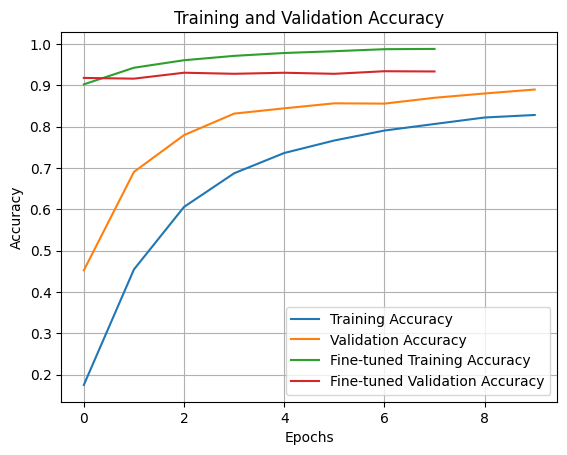

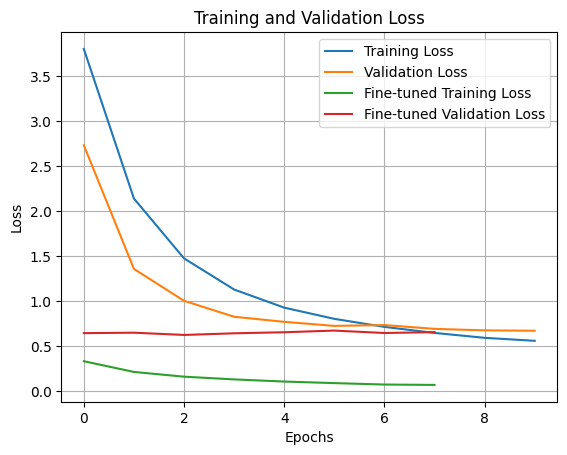

In [20]:
# Plot accuracy and loss curves
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.plot(history_fine.history['accuracy'], label='Fine-tuned Training Accuracy')
plt.plot(history_fine.history['val_accuracy'], label='Fine-tuned Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.grid(True)
plt.show()

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.plot(history_fine.history['loss'], label='Fine-tuned Training Loss')
plt.plot(history_fine.history['val_loss'], label='Fine-tuned Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.grid(True)
plt.show()

Visualize predictions

In [21]:
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import os
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import itertools

def get_index_to_class_mapping(class_indices):
    """Return index -> class_name dict."""
    return {idx: name for name, idx in class_indices.items()}


def predict_single_image(model, img_path, target_size=(128, 128), top_k=3):
    """Predict a single image, return probs and indices."""
    img = load_img(img_path, target_size=target_size)
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    probs = model.predict(img_array, verbose=0)[0]
    top_k_idx = np.argsort(probs)[-top_k:][::-1]
    return img, probs, top_k_idx


def visualize_single_prediction(model, img_path, index_to_class, target_size=(128, 128), top_k=3):
    """Visualize one image with top-k predictions."""
    img = load_img(img_path, target_size=target_size)
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    probs = model.predict(img_array, verbose=0)[0]
    top_k_idx = np.argsort(probs)[-top_k:][::-1]

    top_lines = [
        f"{index_to_class[i]}: {probs[i]:.1%}" for i in top_k_idx
    ]

    plt.figure(figsize=(4, 4), dpi=120)
    plt.imshow(img)
    plt.title("Top predictions:\n" + "\n".join(top_lines), fontsize=9)
    plt.axis('off')
    plt.show()


actual_count = Counter()
predicted_count = Counter()

def visualize_prediction_with_actual(model, img_path, index_to_class, target_size=(128, 128)):
    """Show image with actual (from folder) and predicted label."""
    # True class from folder name
    true_class = os.path.basename(os.path.dirname(img_path))

    img = load_img(img_path, target_size=target_size)
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    probs = model.predict(img_array, verbose=0)[0]
    pred_idx = np.argmax(probs)
    pred_class = index_to_class[pred_idx]
    conf = probs[pred_idx]

    # Update counters
    actual_count[true_class] += 1
    predicted_count[pred_class] += 1

    plt.figure(figsize=(3, 3), dpi=120)
    plt.imshow(img)
    plt.title(f"True: {true_class}\nPred: {pred_class} ({conf:.1%})", fontsize=9)
    plt.axis('off')
    plt.show()


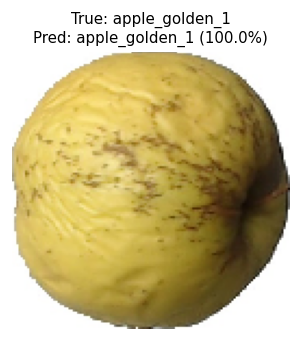

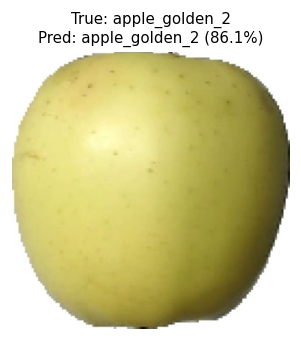

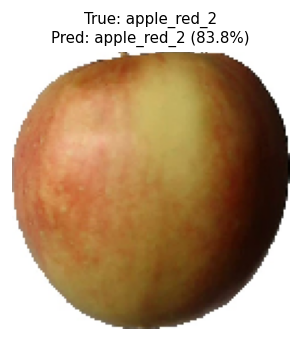

In [22]:
class_index_mapping = train_generator.class_indices
index_to_class = get_index_to_class_mapping(class_index_mapping)

sample_images = [
    'fruits-360-original-size/fruits-360-original-size-main/Test/apple_golden_1/r1_95.jpg',
    'fruits-360-original-size/fruits-360-original-size-main/Test/apple_golden_2/r0_3.jpg',
    'fruits-360-original-size/fruits-360-original-size-main/Test/apple_red_2/r0_11.jpg',
]

for img_path in sample_images:
    visualize_prediction_with_actual(model, img_path, index_to_class, target_size=(128, 128))


Selected 10 random images from 10 classes


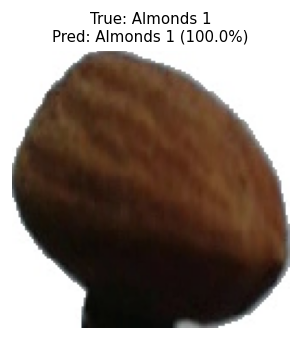

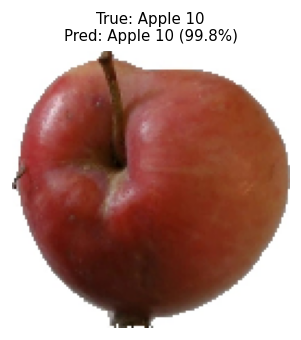

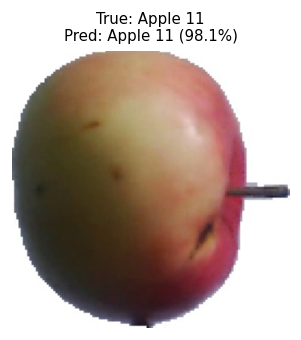

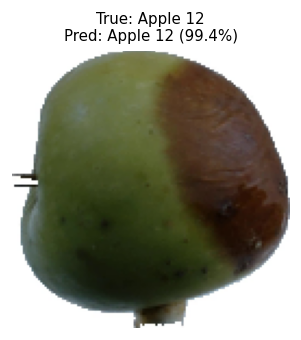

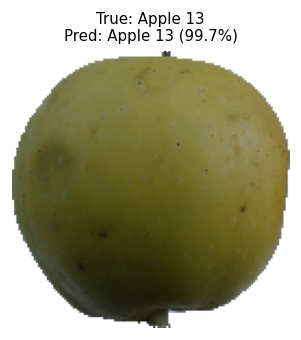

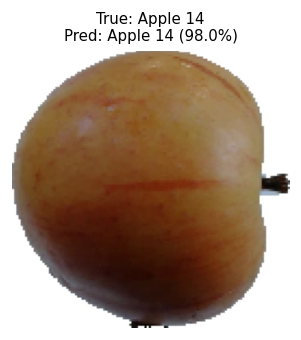

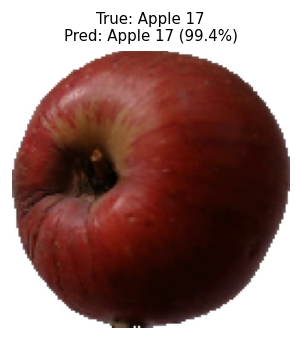

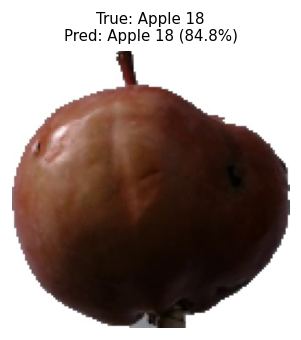

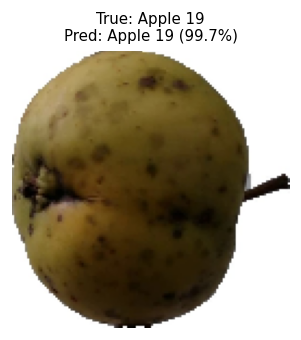

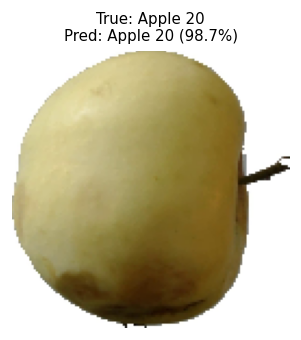

In [23]:
import random
import glob

def get_random_test_images(test_dir, num_samples=10):
    """
    Automatically pick one random image from up to 10 different class folders in Test/
    Returns list of image paths.
    """
    class_dirs = glob.glob(os.path.join(test_dir, "*"))
    class_dirs = [d for d in class_dirs if os.path.isdir(d)][:num_samples]  # Limit to 10 classes
    
    sample_images = []
    for class_dir in class_dirs:
        img_files = glob.glob(os.path.join(class_dir, "*.jpg")) + glob.glob(os.path.join(class_dir, "*.png"))
        if img_files:
            random_img = random.choice(img_files)
            sample_images.append(random_img)
    
    print(f"Selected {len(sample_images)} random images from {len(class_dirs)} classes")
    return sample_images

# Usage - fully automatic!
test_dir = 'fruits-360-original-size/fruits-360-original-size-main/Test'
sample_images = get_random_test_images(test_dir, num_samples=10)

class_index_mapping = train_generator.class_indices
index_to_class = get_index_to_class_mapping(class_index_mapping)

# Visualize
for img_path in sample_images:
    visualize_prediction_with_actual(model, img_path, index_to_class, target_size=(128, 128))


In [24]:
from tensorflow.keras.models import load_model

model = load_model('models/vgg16_fruit_finetuned.h5')

2026-04-12 15:10:30 DEBUG: Creating converter from 3 to 5


Batch evaluation and confusion matrix

In [25]:
def predict_on_generator(model, generator):
    """Return y_true, y_pred, probs for a Keras DirectoryIterator."""
    y_true, y_pred, probs = [], [], []
    steps = int(np.ceil(generator.samples / generator.batch_size))

    for _ in range(steps):
        batch_x, batch_y = next(generator)
        batch_probs = model.predict(batch_x, verbose=0)
        probs.append(batch_probs)
        y_pred.append(np.argmax(batch_probs, axis=1))
        y_true.append(np.argmax(batch_y, axis=1))

    probs = np.concatenate(probs, axis=0)
    y_pred = np.concatenate(y_pred, axis=0)
    y_true = np.concatenate(y_true, axis=0)

    return y_true[:generator.samples], y_pred[:generator.samples], probs[:generator.samples]


def plot_confusion_matrix(y_true, y_pred, index_to_class, normalize=False, figsize=(24, 20), filename=None):
    labels = list(index_to_class.keys())
    class_names = [index_to_class[i] for i in labels]

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    plt.figure(figsize=figsize)
    sns.heatmap(cm, annot=False, cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    title = 'Confusion Matrix (normalized)' if normalize else 'Confusion Matrix'
    plt.title(title)
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    if filename:
        plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()


def print_classification_report(y_true, y_pred, index_to_class):
    target_names = [index_to_class[i] for i in sorted(index_to_class.keys())]
    print(classification_report(y_true, y_pred, target_names=target_names))


def compute_topk_accuracy(y_true, probs, k=3):
    topk = np.argsort(probs, axis=1)[:, -k:]
    in_topk = [y_true[i] in topk[i] for i in range(len(y_true))]
    return np.mean(in_topk)





                        precision    recall  f1-score   support

             Almonds 1       1.00      1.00      1.00        77
              Apple 10       0.94      1.00      0.97       231
              Apple 11       1.00      0.99      0.99       142
              Apple 12       0.99      1.00      1.00       154
              Apple 13       0.99      1.00      1.00       231
              Apple 14       1.00      0.99      1.00       154
              Apple 17       0.93      1.00      0.96       243
              Apple 18       1.00      0.94      0.97       242
              Apple 19       1.00      1.00      1.00       241
              Apple 20       1.00      1.00      1.00       234
              Apple 21       1.00      1.00      1.00       159
              Apple 22       1.00      1.00      1.00       231
              Apple 23       1.00      1.00      1.00       156
               Apple 5       0.98      1.00      0.99       146
               Apple 6       1.00      

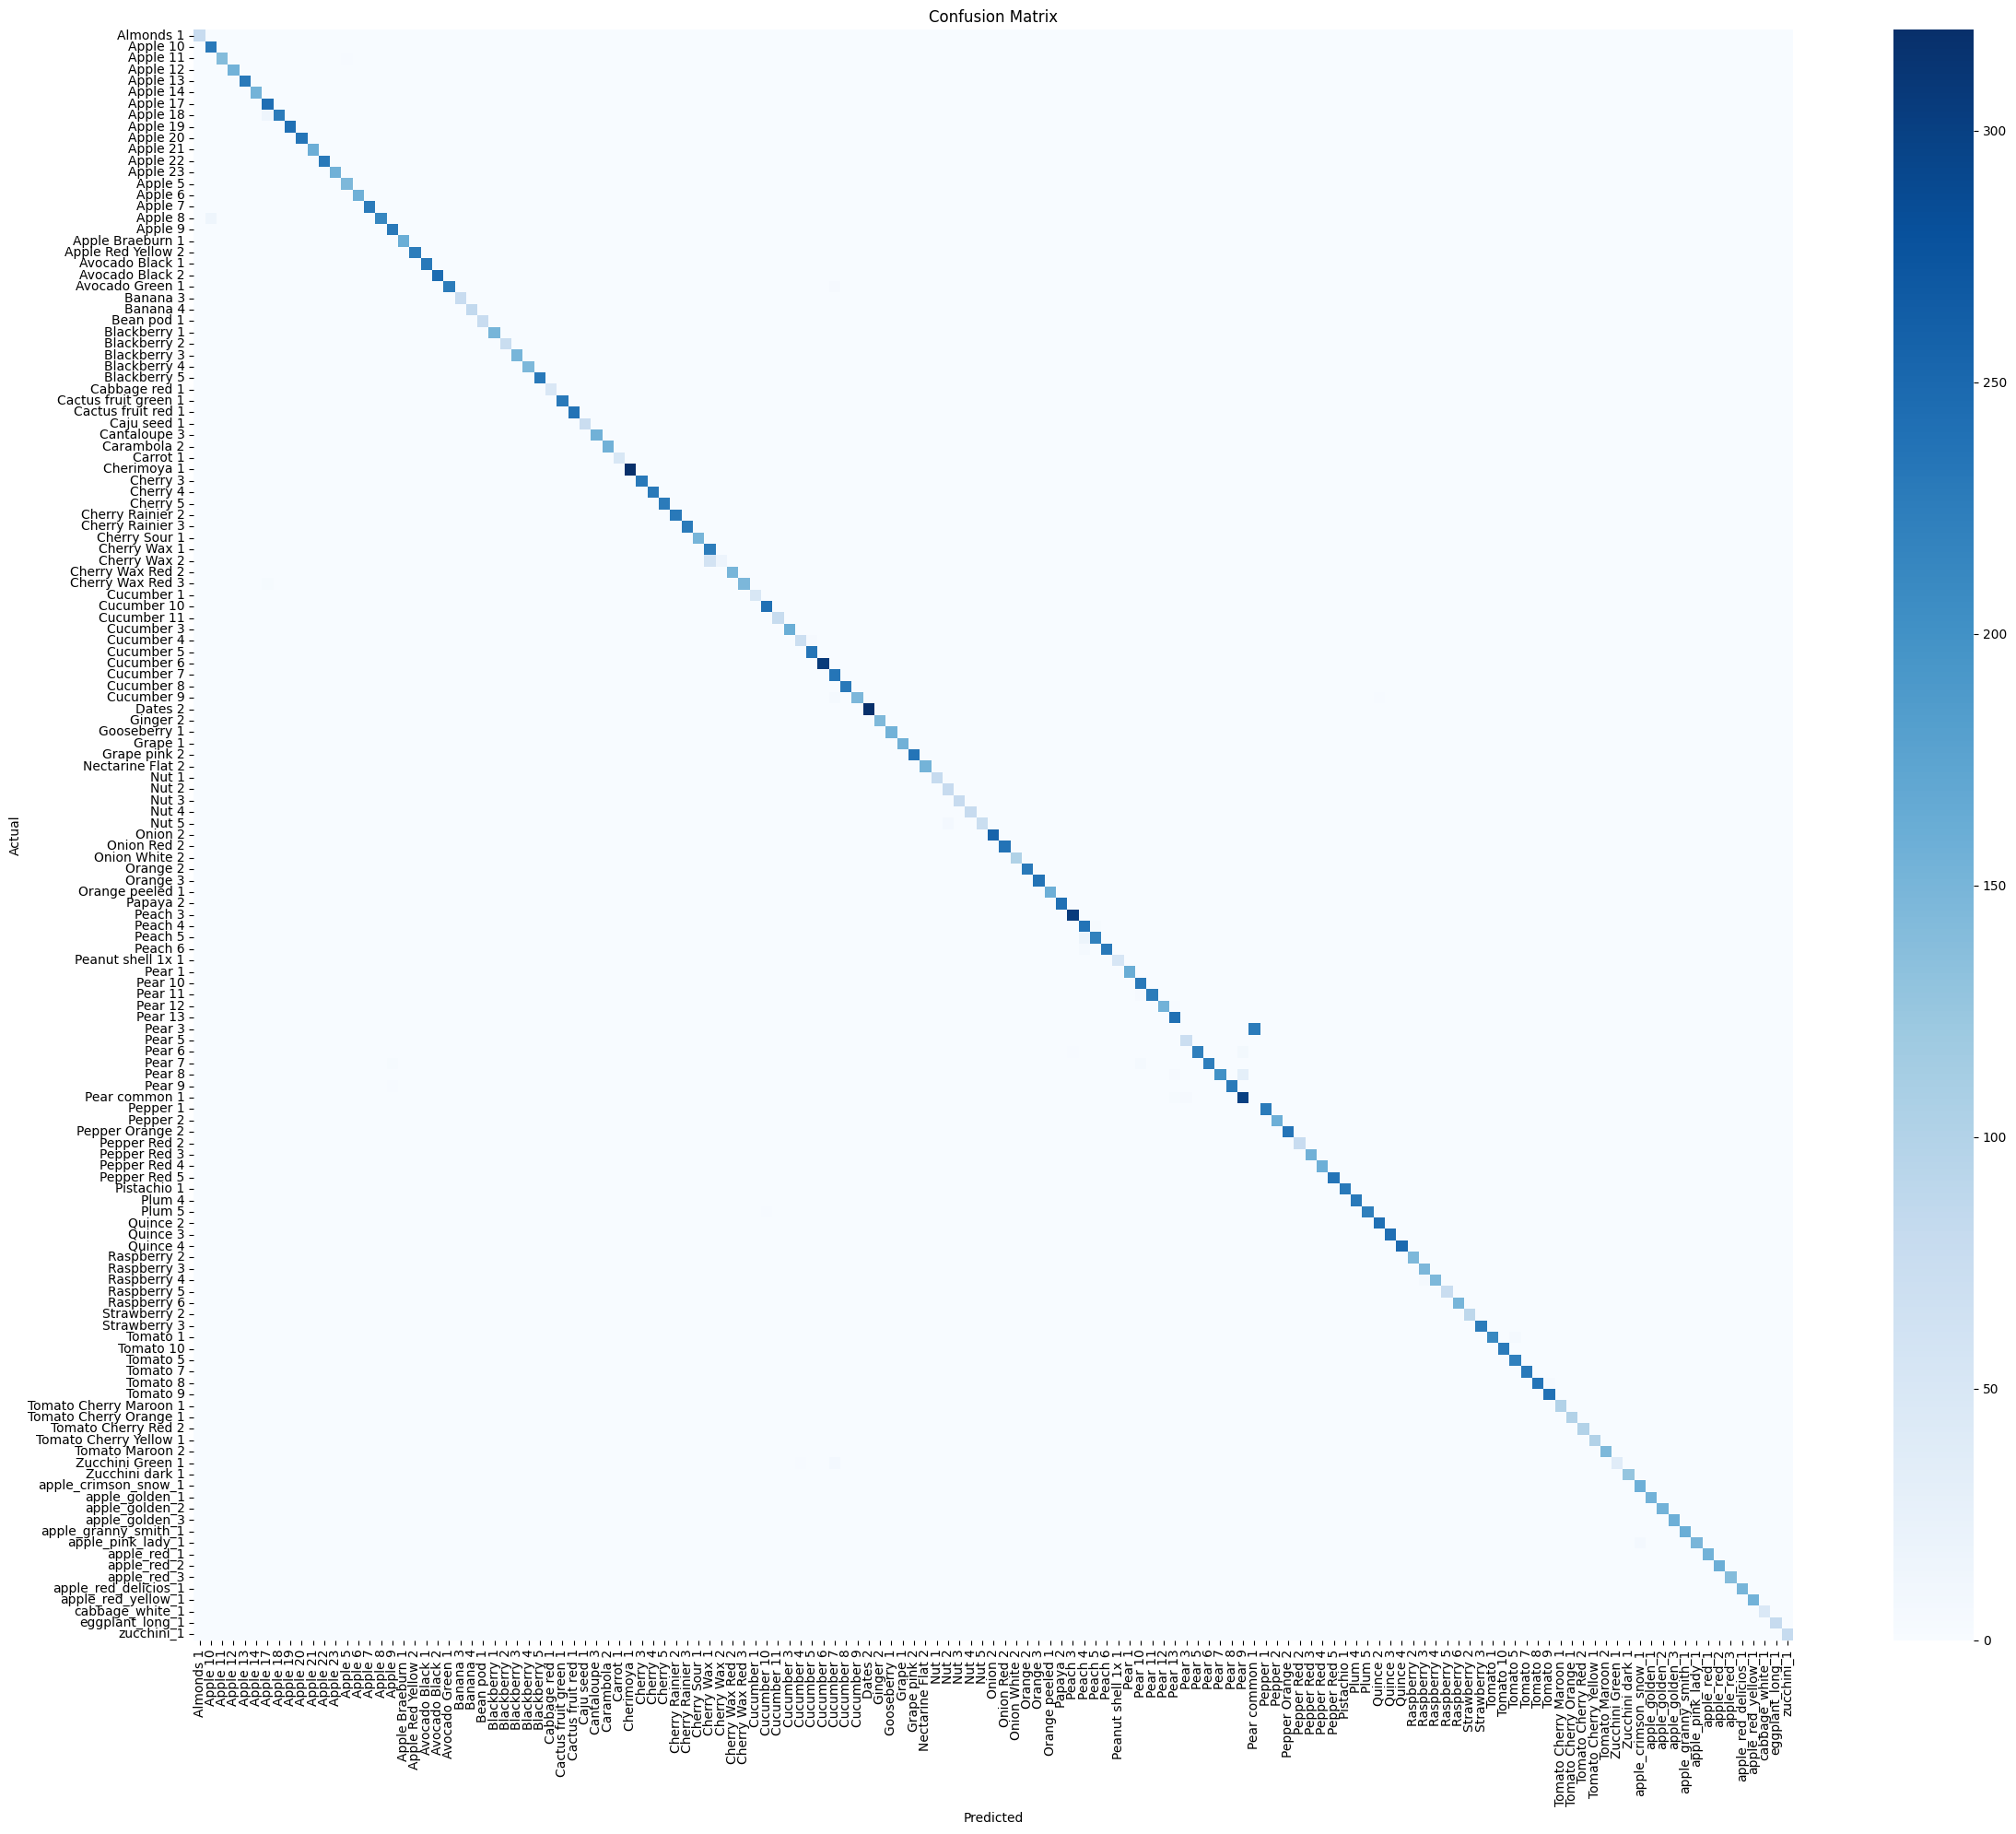

Top-1 accuracy: 0.930
Top-3 accuracy: 0.946


In [26]:

# Reset test_generator so it starts from the first sample
test_generator.reset()

index_to_class = get_index_to_class_mapping(train_generator.class_indices)

y_true, y_pred, probs = predict_on_generator(model, test_generator)

print_classification_report(y_true, y_pred, index_to_class)
plot_confusion_matrix(y_true, y_pred, index_to_class, normalize=False, filename='cm_full.png')

top1 = np.mean(y_true == y_pred)
top3 = compute_topk_accuracy(y_true, probs, k=3)
print(f"Top-1 accuracy: {top1:.3f}")
print(f"Top-3 accuracy: {top3:.3f}")